In [67]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

#from mlxtend.frequent_patterns import apriori, association_rules

In [68]:
!pip install mlxtend

In [38]:
df = pd.read_excel("/content/ecommerce_user_behavior_60k_2024.xlsx")

df.head()

,event_time,event_type,product_id,category_code,brand,price,user_id,user_session
0,2024-01-01 00:18:00,purchase,1275,electronics.smartphone,Apple,429.26,31025,sess_565382
1,2024-01-01 00:26:00,view,2136,sports.fitness,Apple,497.13,35640,sess_914458
2,2024-01-01 00:29:00,view,2969,home.appliances,HP,27.50,29443,sess_838201
3,2024-01-01 00:36:00,view,4054,fashion.shoes,Zara,618.89,37865,sess_701522
4,2024-01-01 01:00:00,view,1033,electronics.laptop,Puma,99.02,38331,sess_658858


In [39]:
df['event_time'] = pd.to_datetime(df['event_time'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   event_time     60000 non-null  datetime64[ns]
 1   event_type     60000 non-null  object        
 2   product_id     60000 non-null  int64         
 3   category_code  60000 non-null  object        
 4   brand          60000 non-null  object        
 5   price          60000 non-null  float64       
 6   user_id        60000 non-null  int64         
 7   user_session   60000 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 3.7+ MB


# Create User Level Dataset

#Group transactions by user.

In [40]:
user_df = df.groupby('user_id').agg({
    'price':'sum',
    'product_id':'count',
    'event_time':'max'
}).reset_index()

user_df.columns = ['user_id','total_spent','total_events','last_activity']

user_df.head()

,user_id,total_spent,total_events,last_activity
0,10000,1105.48,3,2024-11-10 07:13:00
1,10001,1754.82,3,2024-11-12 15:59:00
2,10002,298.84,1,2024-08-05 11:56:00
3,10003,1203.11,2,2024-05-24 08:30:00
4,10004,2113.40,2,2024-11-14 05:09:00


# Recency Calculation

In [41]:
latest_date = df['event_time'].max()

user_df['recency_days'] = (
    latest_date - user_df['last_activity']
).dt.days

# Create Churn Label

In [42]:
user_df['churn'] = np.where(
    user_df['recency_days'] > 30,
    1,
    0
)

In [43]:
user_df

,user_id,total_spent,total_events,last_activity,recency_days,churn
0,10000,1105.48,3,2024-11-10 07:13:00,50,1
1,10001,1754.82,3,2024-11-12 15:59:00,48,1
2,10002,298.84,1,2024-08-05 11:56:00,147,1
3,10003,1203.11,2,2024-05-24 08:30:00,220,1
4,10004,2113.40,2,2024-11-14 05:09:00,46,1
...,...,...,...,...,...,...
25946,39993,1609.40,3,2024-08-23 22:11:00,129,1
25947,39994,920.40,1,2024-06-04 08:55:00,209,1
25948,39995,2287.03,3,2024-07-23 23:23:00,160,1
25949,39996,1987.58,3,2024-11-30 09:43:00,30,0


# RFM Modeling

#Recency → recency_days
#Frequency → total_events
#Monetary → total_spent

In [44]:
rfm = user_df[['recency_days','total_events','total_spent']]

In [45]:
rfm

,recency_days,total_events,total_spent
0,50,3,1105.48
1,48,3,1754.82
2,147,1,298.84
3,220,2,1203.11
4,46,2,2113.40
...,...,...,...
25946,129,3,1609.40
25947,209,1,920.40
25948,160,3,2287.03
25949,30,3,1987.58


In [46]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

# KMeans Segmentation

In [47]:
kmeans = KMeans(n_clusters=4, random_state=42)

user_df['rfm_segment'] = kmeans.fit_predict(rfm_scaled)

## RFM Visualization

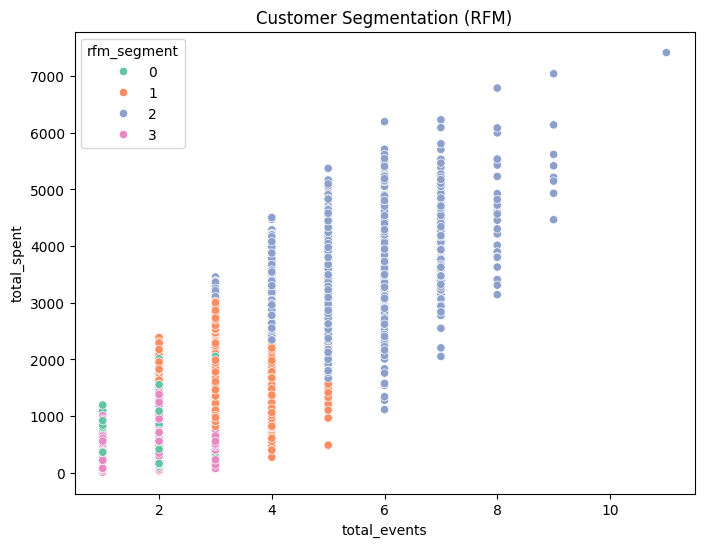

In [48]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=user_df,
    x='total_events',
    y='total_spent',
    hue='rfm_segment',
    palette='Set2'
)

plt.title("Customer Segmentation (RFM)")
plt.show()

# Predictive Churn Model

## Features:

#Recency

#Frequency

#Monetary

In [49]:
features = ['recency_days','total_events','total_spent']

X = user_df[features]

y = user_df['churn']

In [50]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.3,
    random_state=42
)

In [51]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

# Model Evaluation

In [52]:
pred = model.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1391
           1       1.00      1.00      1.00      6395

    accuracy                           1.00      7786
   macro avg       1.00      1.00      1.00      7786
weighted avg       1.00      1.00      1.00      7786



# Churn Probability

In [53]:
user_df['churn_probability'] = model.predict_proba(X)[:,1]

user_df[['user_id','churn_probability']].head()

,user_id,churn_probability
0,10000,1.0
1,10001,1.0
2,10002,1.0
3,10003,1.0
4,10004,1.0


# Risk vs Value Quadrant

In [54]:
scaler2 = StandardScaler()

user_df[['Value_Score','Risk_Score']] = scaler2.fit_transform(
    user_df[['total_spent','churn_probability']]
)

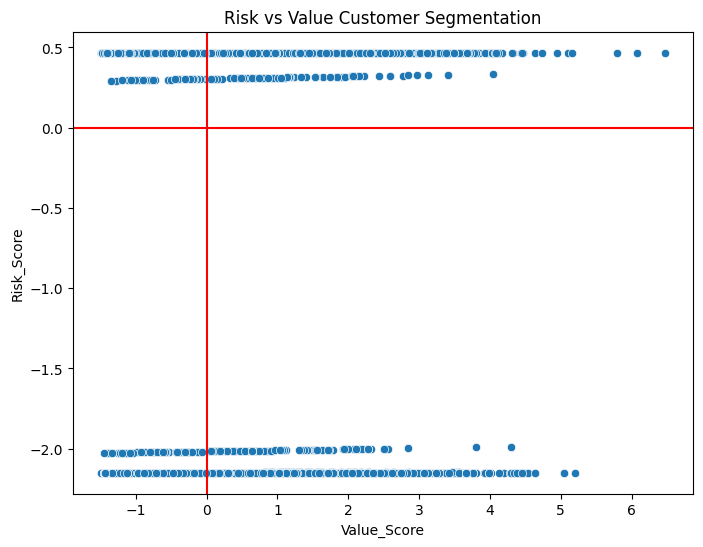

In [55]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=user_df,
    x='Value_Score',
    y='Risk_Score'
)

plt.axhline(0,color='red')
plt.axvline(0,color='red')

plt.title("Risk vs Value Customer Segmentation")
plt.show()

# | Quadrant               | Segment           |
 | High Value + High Risk | At-Risk Champions |
| High Value + Low Risk  | Loyal Customers   |
| Low Value + High Risk  | Lost Customers    |
| Low Value + Low Risk   | Potential Growers |


# Market Basket Analysis

## Convert transactions to basket format.

In [56]:
basket = (
    df.groupby(['user_id','product_id'])
    .size()
    .unstack()
    .fillna(0)
)

In [57]:
basket = basket.applymap(lambda x: 1 if x>0 else 0)

/tmp/ipykernel_164/3988265632.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x>0 else 0)


# Apriori Algorithm

# Association Rules

# Cohort Analysis

In [58]:
df['order_month'] = df['event_time'].dt.to_period('M')

In [59]:
df['cohort_month'] = df.groupby('user_id')['order_month'].transform('min')

In [60]:
#Cohort Index

In [61]:
df['cohort_index'] = (
    (df['order_month'].dt.year - df['cohort_month'].dt.year)*12
    +
    (df['order_month'].dt.month - df['cohort_month'].dt.month)
)

In [62]:
#Cohort Table

In [63]:
cohort_data = df.groupby(
    ['cohort_month','cohort_index']
)['user_id'].nunique().reset_index()

In [64]:
cohort_pivot = cohort_data.pivot_table(
    index='cohort_month',
    columns='cohort_index',
    values='user_id'
)

# Retention Rate

In [65]:
cohort_size = cohort_pivot.iloc[:,0]

retention = cohort_pivot.divide(cohort_size, axis=0)

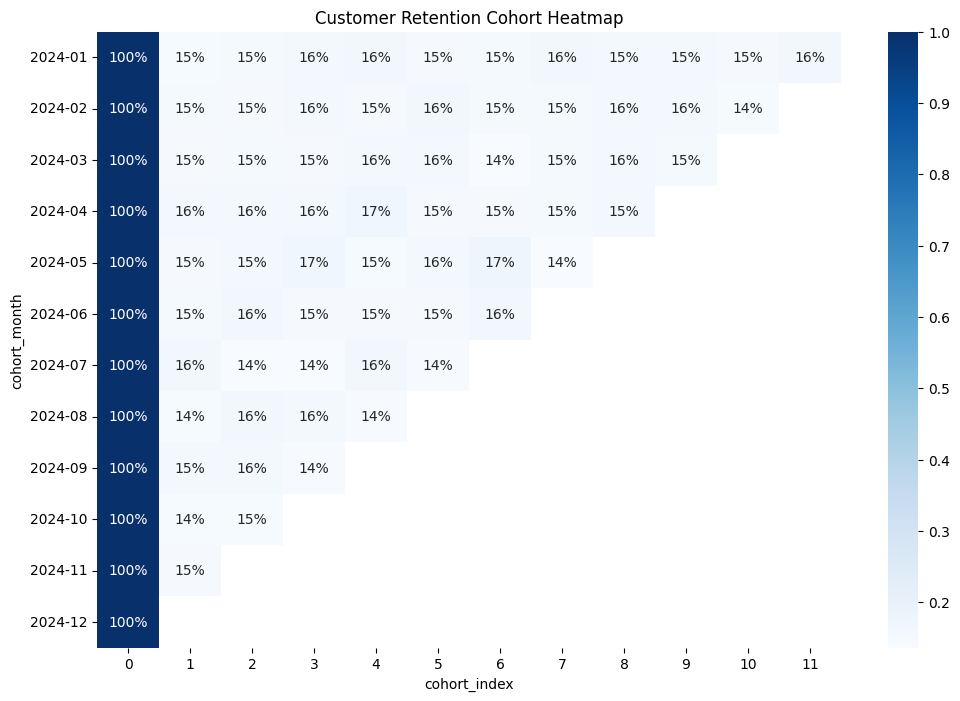

In [66]:
plt.figure(figsize=(12,8))

sns.heatmap(
    retention,
    annot=True,
    fmt='.0%',
    cmap='Blues'
)

plt.title("Customer Retention Cohort Heatmap")
plt.show()